# TEST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util

In [2]:
# ============================================================
# Cargar pipeline.py
# ============================================================
from pipeline import *

In [3]:
# ============================================================
# Parámetros OFDM según Modulator.yaml
# ============================================================

FFT_SIZE = 1024
CP_LEN = 256
NUM_SYMBOLS = 100

FS_BB = 50_000_000.0                  # Hz, sample_rate del YAML
DELTA_F = FS_BB / FFT_SIZE            # 48_828.125 Hz

T_U = 1.0 / DELTA_F                   # duración útil OFDM = 20.48 us
T_SYM = (FFT_SIZE + CP_LEN) / FS_BB   # duración total con CP = 25.6 us

FS_SLOW = 1.0 / T_SYM                 # 39_062.5 Hz si usas todos los símbolos

# Si aplicas sensing_symbol_stride = 20:
SENSING_SYMBOL_STRIDE = 20
FS_SLOW_SENSING = FS_SLOW / SENSING_SYMBOL_STRIDE  # 1953.125 Hz

CENTER_FREQ = 3_500_000_000.0         # Hz

RANGE_FFT_SIZE = 1024
DOPPLER_FFT_SIZE = 100

SYNC_SYMBOL_INDEX = 1
ZC_ROOT = 25

PILOT_SUBCARRIERS = np.array([
    571, 631, 692, 752, 812, 872, 933, 993,
    29, 89, 150, 210, 270, 330, 391, 451
], dtype=int)

TX_FILE = "iq_tx.bin"
RX_FILE = "iq_rx.bin"

# Para iq_rx.bin si viene crudo de USRP según wire_format_rx: sc16
USRP_FILE_DTYPE = "sc16_interleaved"  # cada muestra es un complejo de 32 bits (16 bits I + 16 bits Q)

In [4]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
obs = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE,
    rx_file_path=RX_FILE,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

print("x_grid shape:", obs.x_grid.shape)
print("y_grid shape:", obs.y_grid.shape)

x_grid shape: (100, 1024)
y_grid shape: (100, 1024)


In [14]:
# ============================================================
# Elegir tamaño STFT de forma robusta según longitud disponible
# ============================================================
n_slow_total = obs.y_grid.shape[0]

# Resolución Doppler objetivo [Hz]
DF_TARGET = 5.0

nperseg = int(2 ** np.ceil(np.log2(FS_SLOW / DF_TARGET)))

# No permitir que la ventana ocupe más de la mitad de la señal
nperseg = min(nperseg, 2 ** int(np.floor(np.log2(n_slow_total // 2))))

# Límites prácticos
nperseg = int(np.clip(nperseg, 64, 8192))

noverlap = int(0.99 * nperseg)
nfft = 2 * nperseg

print(f"n_slow_total={n_slow_total}")
print(f"nperseg={nperseg}, noverlap={noverlap}, nfft={nfft}")
print(f"Resolución Doppler aprox = {FS_SLOW / nperseg:.2f} Hz")
print(f"Espaciado de bins = {FS_SLOW / nfft:.2f} Hz")

n_slow_total=100
nperseg=64, noverlap=63, nfft=128
Resolución Doppler aprox = 610.35 Hz
Espaciado de bins = 305.18 Hz


In [15]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db, f_axis, t_axis), inter = microdoppler_spectrogram_from_full_grid(
    y_grid=obs.y_grid,
    x_grid=obs.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

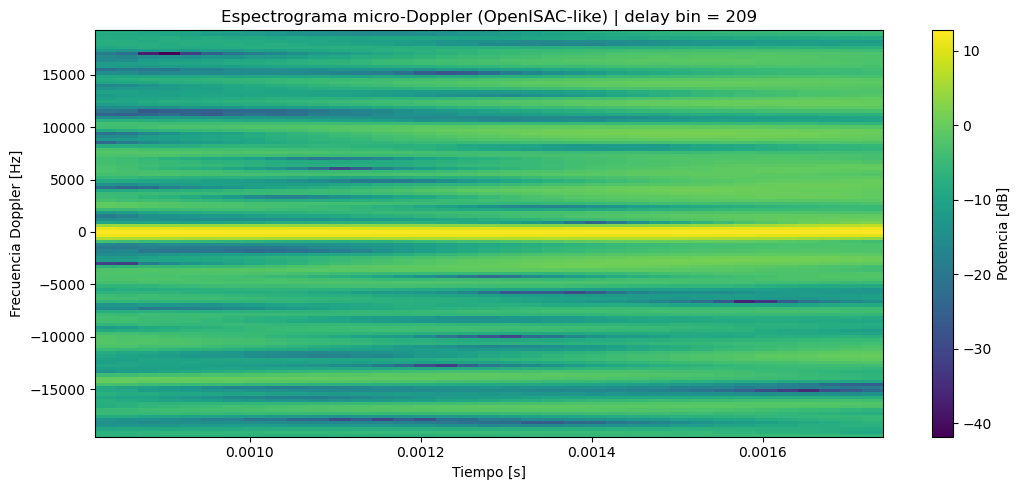

Delay bin seleccionado: 209


In [16]:
# ============================================================
# Visualización
# ============================================================
plt.figure(figsize=(11, 5))
extent = [t_axis[0], t_axis[-1], f_axis[0], f_axis[-1]]

plt.imshow(
    spec_db,
    aspect="auto",
    origin="lower",
    extent=extent,
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia Doppler [Hz]")
plt.title(
    f"Espectrograma micro-Doppler (OpenISAC-like) | "
    f"delay bin = {inter['selected_delay_bin']}"
)
plt.colorbar(label="Potencia [dB]")
plt.tight_layout()
plt.show()

print("Delay bin seleccionado:", inter["selected_delay_bin"])

h_grid: (100, 1024)
s_grid: (99, 1024)
slow_seq: (99,)
spec: (128, 36)


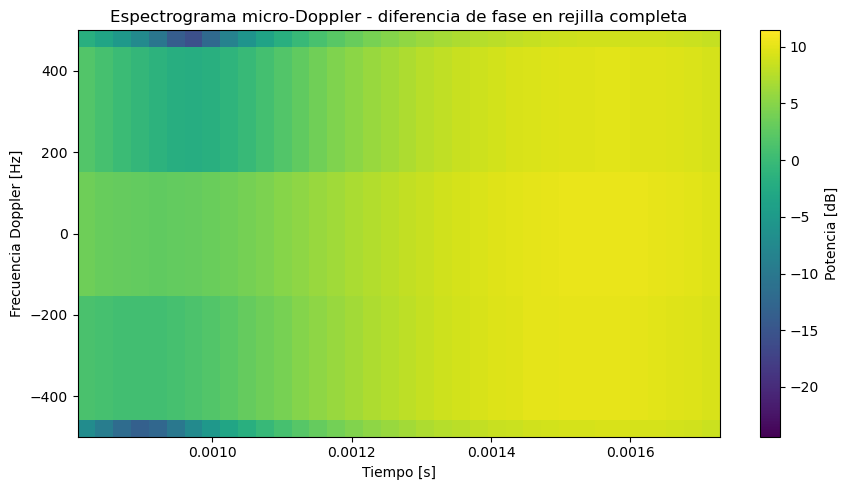

In [17]:
# ============================================================
# Pipeline micro-Doppler con DIFERENCIA DE FASE en rejilla completa
# ============================================================

(spec, f_axis, t_axis), inter = microdoppler_spectrogram_from_full_grid(
    y_grid=obs.y_grid,
    x_grid=obs.x_grid,
    fs_slow=FS_SLOW,

    # CAMBIO IMPORTANTE:
    method="phase_difference",

    # Diferencia de fase:
    # current_next: S[m,k] = H[m,k] * conj(H[m+1,k])
    # next_current: cambia el signo del eje Doppler
    use_conjugate_order="current_next",

    # Agregación sobre todas las subportadoras
    aggregation_mode="coherent_mean",
    min_valid_subcarriers=1,

    # Parámetros STFT
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

print("h_grid:", inter["h_grid"].shape)
print("s_grid:", inter["s_grid"].shape)
print("slow_seq:", inter["slow_seq"].shape)
print("spec:", spec.shape)

# ============================================================
# Representación
# ============================================================

plt.figure(figsize=(9, 5))
plt.pcolormesh(t_axis, f_axis, spec, shading="auto")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia Doppler [Hz]")
plt.title("Espectrograma micro-Doppler - diferencia de fase en rejilla completa")
plt.colorbar(label="Potencia [dB]")
plt.ylim(-500, 500)   # ajusta según lo que quieras ver
plt.tight_layout()
plt.show()